In [51]:
#=================================================================================================
# Libraries:
# 1. pandas — to load, clean, and organize the CSV data into tables you can analyze easily.
# 2. matplotlib — to create the bar chart, box plots, and histogram plots.
# 3. scipy — to calculate the Pearson correlation and other statistical values.
# 4. numpy — to handle numerical operations efficiently behind the scenes.
# 5. seaborn — to make the plots look cleaner and more polished with less code.
#=================================================================================================
# Types of Plots:
# 1. Bar Chart: To compare the average values of a specific column across different categories.
# 2. Box Plot: To visualize the distribution of a numerical column and identify outliers
# 3. Histogram: To show the frequency distribution of a numerical column and understand its shape.
# 4. Pearson Correlation: To measure the strength and direction of the linear relationship between two numerical columns.
#=================================================================================================
# Graphs we can make now - Transcribed from 08/04/2026 Meeting:
# Histogram - Count on y axis and {Variable} on x axis - At least 5 Figures

# https://chatgpt.com/c/69dd0506-45f4-8392-9f9b-efca2313721a

In [72]:
import pandas as pd

file_path = "Complete Extraction Results.xlsx"

# Open the Excel file
excel_file = pd.ExcelFile(file_path, engine="openpyxl")

# Show all sheet names
print("Available sheets:")
for i, sheet in enumerate(excel_file.sheet_names, start=1):
    print(f"{i}. {sheet}")

# Select a sheet by number
choice = int(input("Enter sheet number: "))
selected_sheet = excel_file.sheet_names[choice - 1]

# Read that sheet
df = pd.read_excel(file_path, sheet_name=selected_sheet, engine="openpyxl", header=1)

print(f"\nLoaded sheet: {selected_sheet}")
print(df.head())
print(f"\nColumns in the sheet: {df.columns.tolist()[0:10]}")  # Show first 10 columns for brevity

# Make dictionary: key -> column name
column_dict = {i: col for i, col in enumerate(df.columns, start=1)}

print("\nColumn dictionary:")
for k, v in column_dict.items():
    print(f"{k}: {v}")


Available sheets:
1. Structure
2. Graphs (6 Types)
3. ReadMe
4. Extra


Enter sheet number:  2



Loaded sheet: Graphs (6 Types)
   datapoint_id  id exact_polymer_name                         Polymer Family  \
0           NaN  A1          PDPPSe-12  Diketopyrrolopyrrole (DPP) derivative   
1           NaN  A1          PDPPSe-12  Diketopyrrolopyrrole (DPP) derivative   
2           NaN  A1          PDPPSe-12  Diketopyrrolopyrrole (DPP) derivative   
3           NaN  A1          PDPPSe-12  Diketopyrrolopyrrole (DPP) derivative   
4           NaN  A1          PDPPSe-12  Diketopyrrolopyrrole (DPP) derivative   

   Chemical Structure (Image) Repeating Unit Formula  \
0                         NaN         C53H78N2O2S2Se   
1                         NaN         C53H78N2O2S2Se   
2                         NaN         C53H78N2O2S2Se   
3                         NaN         C53H78N2O2S2Se   
4                         NaN         C53H78N2O2S2Se   

   Molecular Weight of the Repeating Unit (g/mol)  \
0                                          918.31   
1                                     

# Figures: Count Vs {Variable}

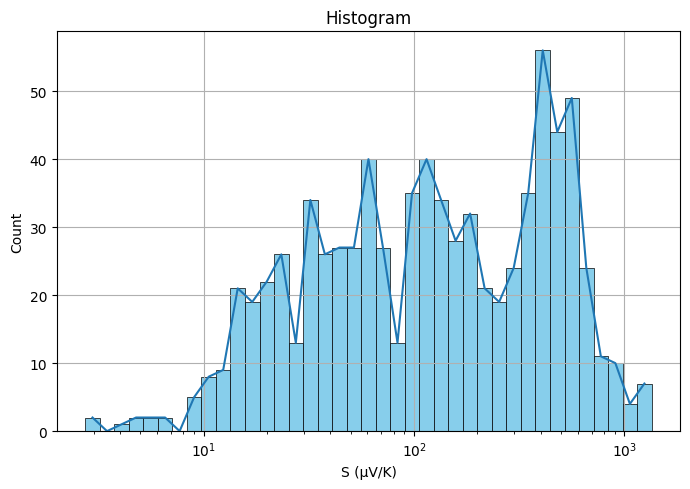

In [73]:
# Count Vs Elecrical Seebeck
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

col_name = column_dict[49]
x = pd.to_numeric(df[col_name], errors='coerce')
x = x.replace([np.inf, -np.inf], np.nan).dropna()
x = x[x > 0]

# Log-spaced bins
bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 40)

# Histogram counts
counts, bin_edges = np.histogram(x, bins=bins)

# Bin centers
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])   # better for log scale

plt.figure(figsize=(7, 5))

# Histogram
plt.hist(x, bins=bins, color='skyblue', edgecolor='black', linewidth=0.5)

# Line connecting bar tips
plt.plot(bin_centers, counts, linewidth=1.5)
plt.grid()

plt.xscale('log')
plt.xlabel("S (µV/K)")
plt.ylabel('Count')
plt.title("Histogram")

plt.tight_layout()
plt.show()

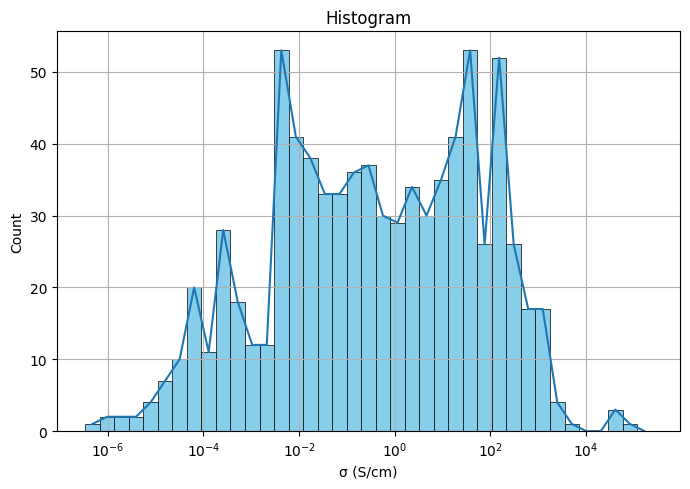

In [74]:
# Count Vs Elecrical Conductivity

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

col_name = column_dict[50]
x = pd.to_numeric(df[col_name], errors='coerce')
x = x.replace([np.inf, -np.inf], np.nan).dropna()
x = x[x > 0]

# Log-spaced bins
bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 40)

# Histogram counts
counts, bin_edges = np.histogram(x, bins=bins)

# Bin centers
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])   # better for log scale

plt.figure(figsize=(7, 5))

# Histogram
plt.hist(x, bins=bins, color='skyblue', edgecolor='black', linewidth=0.5)

# Line connecting bar tips
plt.plot(bin_centers, counts, linewidth=1.5)
plt.grid()

plt.xscale('log')
plt.xlabel("σ (S/cm)")
plt.ylabel('Count')
plt.title("Histogram")

plt.tight_layout()
plt.show()

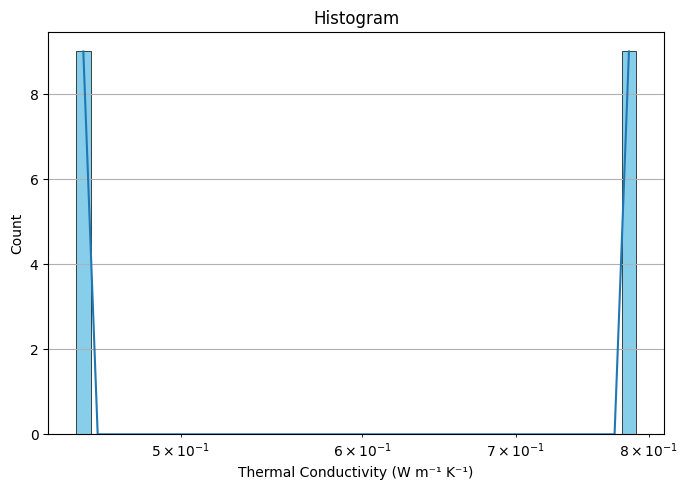

In [75]:
# Count Vs Thermal Conductivity (W m⁻¹ K⁻¹)


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

col_name = column_dict[33]
x = pd.to_numeric(df[col_name], errors='coerce')
x = x.replace([np.inf, -np.inf], np.nan).dropna()
x = x[x > 0]

# Log-spaced bins
bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 40)

# Histogram counts
counts, bin_edges = np.histogram(x, bins=bins)

# Bin centers
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])   # better for log scale

plt.figure(figsize=(7, 5))

# Histogram
plt.hist(x, bins=bins, color='skyblue', edgecolor='black', linewidth=0.5)

# Line connecting bar tips
plt.plot(bin_centers, counts, linewidth=1.5)
plt.grid()

plt.xscale('log')
plt.xlabel("Thermal Conductivity (W m⁻¹ K⁻¹)")
plt.ylabel('Count')
plt.title("Histogram")

plt.tight_layout()
plt.show()

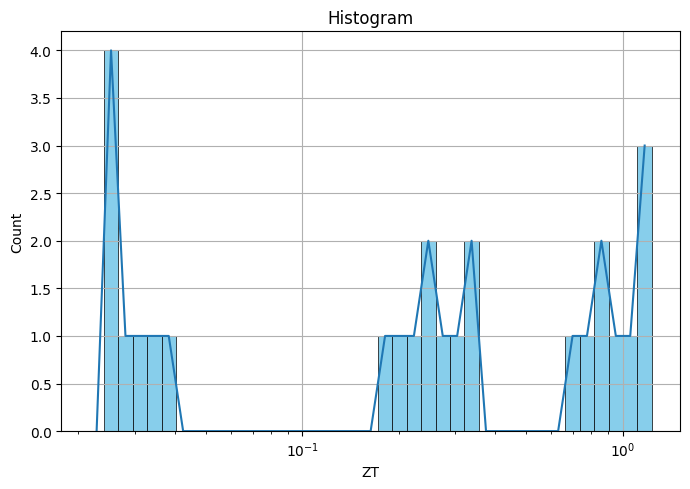

In [76]:
# Count Vs ZT


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

col_name = column_dict[45]
x = pd.to_numeric(df[col_name], errors='coerce')
x = x.replace([np.inf, -np.inf], np.nan).dropna()
x = x[x > 0]

# Log-spaced bins
bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 40)

# Histogram counts
counts, bin_edges = np.histogram(x, bins=bins)

# Bin centers
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])   # better for log scale

plt.figure(figsize=(7, 5))

# Histogram
plt.hist(x, bins=bins, color='skyblue', edgecolor='black', linewidth=0.5)

# Line connecting bar tips
plt.plot(bin_centers, counts, linewidth=1.5)
plt.grid()

plt.xscale('log')
plt.xlabel("ZT")
plt.ylabel('Count')
plt.title("Histogram")

plt.tight_layout()
plt.show()

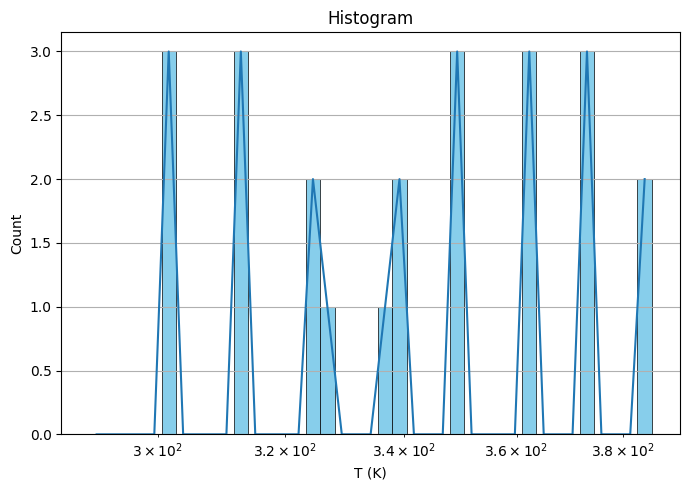

In [77]:
# Count Vs T


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

col_name = column_dict[46]
x = pd.to_numeric(df[col_name], errors='coerce')
x = x.replace([np.inf, -np.inf], np.nan).dropna()
x = x[x > 0]

# Log-spaced bins
bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 40)

# Histogram counts
counts, bin_edges = np.histogram(x, bins=bins)

# Bin centers
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])   # better for log scale

plt.figure(figsize=(7, 5))

# Histogram
plt.hist(x, bins=bins, color='skyblue', edgecolor='black', linewidth=0.5)

# Line connecting bar tips
plt.plot(bin_centers, counts, linewidth=1.5)
plt.grid()

plt.xscale('log')
plt.xlabel("T (K)")
plt.ylabel('Count')
plt.title("Histogram")

plt.tight_layout()
plt.show()

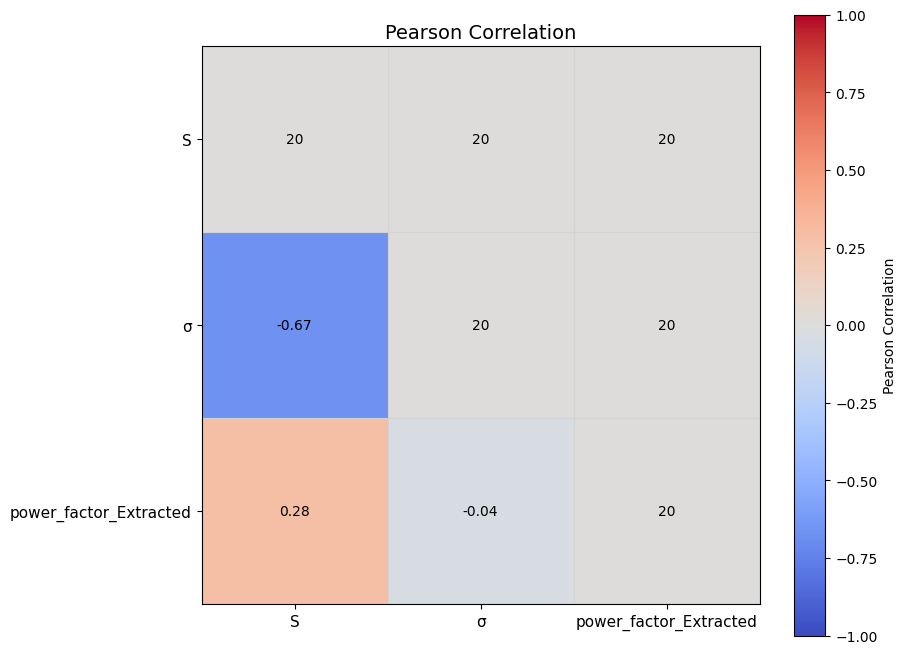

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 1. Pick the columns you want in the plot
#    Add more keys here anytime
# =========================================
selected_keys = [36,39,42]   # example
selected_cols = [column_dict[k] for k in selected_keys]

# Optional: shorter labels for the axes
label_map = {
    "measurement_temperature_K": "T",
    "electrical_conductivity": "σ",
    "seebeck_coefficient": "S",
    "thermal_conductivity": "κ",
    "power_factor": "PF",
    "zt": "zT"
}

axis_labels = [label_map.get(col, col) for col in selected_cols]

# =========================================
# 2. Clean the data
# =========================================
data = df[selected_cols].copy()

data = data.iloc[:20]

for col in selected_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.replace([np.inf, -np.inf], np.nan)

# =========================================
# 3. Build matrices
#    lower triangle  = Pearson correlation
#    diagonal        = number of valid entries
#    upper triangle  = overlap count
# =========================================
n = len(selected_cols)

heatmap_values = np.zeros((n, n), dtype=float)   # for colors
text_values = [["" for _ in range(n)] for _ in range(n)]  # for displayed numbers

for i in range(n):
    for j in range(n):
        col_i = selected_cols[i]
        col_j = selected_cols[j]

        if i == j:
            valid_count = data[col_i].notna().sum()
            text_values[i][j] = f"{valid_count}"
            heatmap_values[i][j] = 0   # keep diagonal neutral

        else:
            pair = data[[col_i, col_j]].dropna()
            overlap = len(pair)

            if i > j:
                # lower triangle = Pearson correlation
                if overlap >= 2 and pair[col_i].nunique() > 1 and pair[col_j].nunique() > 1:
                    r = pair[col_i].corr(pair[col_j], method="pearson")
                    heatmap_values[i][j] = r
                    text_values[i][j] = f"{r:.2f}"
                else:
                    heatmap_values[i][j] = 0
                    text_values[i][j] = "NA"
            else:
                # upper triangle = overlap count
                heatmap_values[i][j] = 0   # neutral color
                text_values[i][j] = f"{overlap}"

# =========================================
# 4. Plot
# =========================================
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(heatmap_values, cmap="coolwarm", vmin=-1, vmax=1)

# ticks
ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(axis_labels, fontsize=11)
ax.set_yticklabels(axis_labels, fontsize=11)

# rotate x labels if needed
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

# annotate each cell
for i in range(n):
    for j in range(n):
        ax.text(j, i, text_values[i][j], ha="center", va="center", color="black", fontsize=10)

# grid lines
ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

# colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pearson Correlation", rotation=90)

ax.set_title("Pearson Correlation", fontsize=14)
plt.tight_layout()
plt.show()

Aligned table used for Pearson:
       doping           S           σ          PF
0    4.425360  251.379310  135.495531   31.966174
1    4.442383  130.344828  137.014018   31.548450
2    4.454168   46.551724  138.065279   31.259257
3    5.910301   43.448276   96.347508   33.521158
4    5.949149  217.241379   97.695846   30.654359
5    5.961371  130.344828   98.120042   50.787135
6    7.409646  183.103448   88.559345  182.997190
7    7.417503  127.241379   88.659966  183.135488
8    7.430162   37.241379   88.822078  183.358300
9    8.929507  176.896552  334.251181   50.419604
10   8.936927  124.137931  332.975873   49.809887
11   9.012876   34.137931   94.831139   54.930886
12  10.393060  121.034483  161.322470   67.110077
13  10.405282   34.137931  161.911261   65.347145
14  10.448931  173.793103  164.014087   59.050959
15  11.843518  158.275862  129.678216  320.613671
16  11.912484  117.931034  331.713851  320.196896
17  11.924705   31.034483  375.189515  324.454855
18  13.427106  148

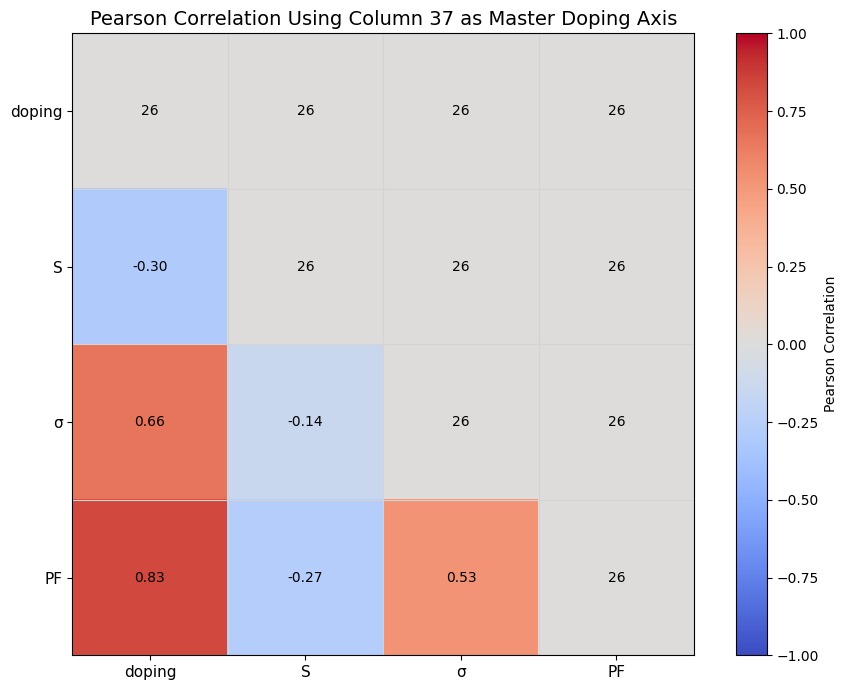

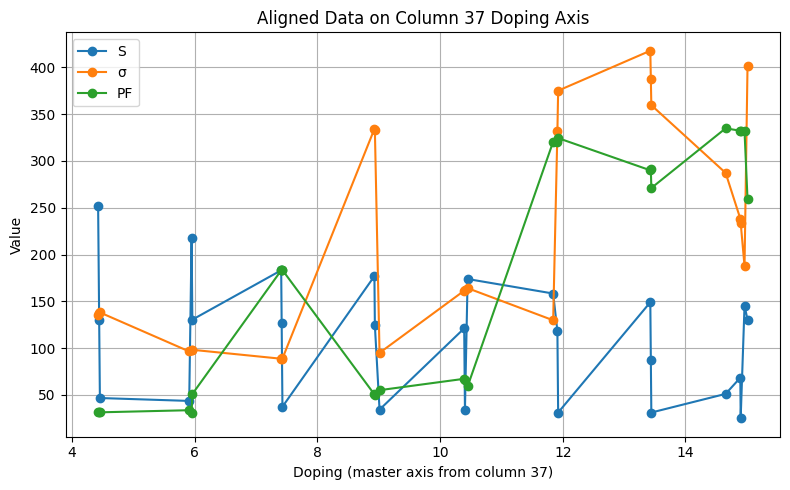

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 1. Column keys
# =========================================
S_key = 36
doping_master_key = 37

sigma_key = 39
sigma_doping_key = 40

PF_key = 42
PF_doping_key = 43

max_rows = 29     # put 20 if you want only first 20 valid rows from each block
include_doping = True

# =========================================
# 2. Column names
# =========================================
S_col = column_dict[S_key]
doping_master_col = column_dict[doping_master_key]

sigma_col = column_dict[sigma_key]
sigma_doping_col = column_dict[sigma_doping_key]

PF_col = column_dict[PF_key]
PF_doping_col = column_dict[PF_doping_key]

# =========================================
# 3. Helper function
#    keep only numeric and non-empty rows
# =========================================
def clean_xy(x_col, y_col, max_rows=None):
    temp = df[[x_col, y_col]].copy()
    temp.columns = ["x", "y"]

    temp["x"] = pd.to_numeric(temp["x"], errors="coerce")
    temp["y"] = pd.to_numeric(temp["y"], errors="coerce")

    temp = temp.replace([np.inf, -np.inf], np.nan)
    temp = temp.dropna(subset=["x", "y"])

    if max_rows is not None:
        temp = temp.iloc[:max_rows].copy()

    # sort by x
    temp = temp.sort_values("x").reset_index(drop=True)

    # if same x appears multiple times, average it
    temp = temp.groupby("x", as_index=False)["y"].mean()

    return temp

# =========================================
# 4. Build clean curves
# =========================================
S_data = clean_xy(doping_master_col, S_col, max_rows=max_rows)
sigma_data = clean_xy(sigma_doping_col, sigma_col, max_rows=max_rows)
PF_data = clean_xy(PF_doping_col, PF_col, max_rows=max_rows)

# =========================================
# 5. Master doping axis from column 37
#    only keep points that lie inside BOTH
#    sigma and PF doping ranges
# =========================================
master_x = S_data["x"].values

sigma_min, sigma_max = sigma_data["x"].min(), sigma_data["x"].max()
PF_min, PF_max = PF_data["x"].min(), PF_data["x"].max()

valid_mask = (
    (master_x >= sigma_min) & (master_x <= sigma_max) &
    (master_x >= PF_min) & (master_x <= PF_max)
)

aligned_doping = master_x[valid_mask]
aligned_S = S_data.loc[valid_mask, "y"].values

# interpolate sigma and PF onto master doping axis
aligned_sigma = np.interp(aligned_doping, sigma_data["x"].values, sigma_data["y"].values)
aligned_PF = np.interp(aligned_doping, PF_data["x"].values, PF_data["y"].values)

# =========================================
# 6. Final aligned dataframe
# =========================================
aligned_df = pd.DataFrame({
    "doping": aligned_doping,
    "S": aligned_S,
    "σ": aligned_sigma,
    "PF": aligned_PF
})

print("Aligned table used for Pearson:")
print(aligned_df)

# =========================================
# 7. Choose columns for correlation
# =========================================
if include_doping:
    corr_cols = ["doping", "S", "σ", "PF"]
else:
    corr_cols = ["S", "σ", "PF"]

plot_data = aligned_df[corr_cols].copy()

# =========================================
# 8. Build matrices
#    lower triangle = Pearson correlation
#    diagonal       = valid count
#    upper triangle = overlap count
# =========================================
n = len(corr_cols)

heatmap_values = np.zeros((n, n), dtype=float)
text_values = [["" for _ in range(n)] for _ in range(n)]

for i in range(n):
    for j in range(n):
        col_i = corr_cols[i]
        col_j = corr_cols[j]

        if i == j:
            valid_count = plot_data[col_i].notna().sum()
            text_values[i][j] = f"{valid_count}"
            heatmap_values[i][j] = 0

        else:
            pair = plot_data[[col_i, col_j]].dropna()
            overlap = len(pair)

            if i > j:
                if overlap >= 2 and pair[col_i].nunique() > 1 and pair[col_j].nunique() > 1:
                    r = pair[col_i].corr(pair[col_j], method="pearson")
                    heatmap_values[i][j] = r
                    text_values[i][j] = f"{r:.2f}"
                else:
                    heatmap_values[i][j] = 0
                    text_values[i][j] = "NA"
            else:
                heatmap_values[i][j] = 0
                text_values[i][j] = f"{overlap}"

# =========================================
# 9. Plot heatmap
# =========================================
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(heatmap_values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(corr_cols, fontsize=11)
ax.set_yticklabels(corr_cols, fontsize=11)

for i in range(n):
    for j in range(n):
        ax.text(j, i, text_values[i][j],
                ha="center", va="center",
                color="black", fontsize=10)

ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pearson Correlation", rotation=90)

ax.set_title("Pearson Correlation Using Column 37 as Master Doping Axis", fontsize=14)
plt.tight_layout()
plt.show()

# =========================================
# 10. Optional: plot aligned curves
# =========================================
plt.figure(figsize=(8, 5))
plt.plot(aligned_df["doping"], aligned_df["S"], marker="o", label="S")
plt.plot(aligned_df["doping"], aligned_df["σ"], marker="o", label="σ")
plt.plot(aligned_df["doping"], aligned_df["PF"], marker="o", label="PF")
plt.xlabel("Doping (master axis from column 37)")
plt.ylabel("Value")
plt.title("Aligned Data on Column 37 Doping Axis")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Dataset Stats - Need to put in paper

In [49]:
col_name = column_dict[62]

# Convert column to numeric and ignore non-numeric cells
x = pd.to_numeric(df[col_name], errors='coerce')

# Sum all values
total = x.sum()

print("Column:", col_name)
print("Sum =", total)

Column: Number of Additional Papers Covered
Sum = 64.0
